In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, RationalQuadratic as RQ, Matern
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared as Exp
from sklearn.gaussian_process.kernels import Kernel
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset

Hyperparameter Optimisation

Random Search
Grid-assisted Manual Search

Sequential Model-Based Optimization (SMBO)
- Gaussian Proccess (GP)
- Tree-structured Parzen Estimator (TPE)

# Initialize

In [4]:
### GLOBAL PATH INPUTS

pData = 'data/'

pAl          = pData + 'Al/'
pAK          = pAl + 'AK/'
pUTdisNodes  = pAK + 'Ductile-disNodes-FCC-12X16/'
pUTdisNodes2 = pAK + '20_RD02_10mm/'
pUTdisStruts = pAK + 'Ductile-disStruts-FCC-12X16/'
pFTdisNodes  = pAK + 'Fracture-disNodes/'

In [5]:
PATH  = pUTdisNodes2
dis   = 'dN'

CSV_train_in  = PATH + f'NN-UT-{dis}-trainIN.csv'
CSV_train_out = PATH + f'NN-UT-{dis}-trainOUT.csv'
CSV_val_in  = PATH + f'NN-UT-{dis}-valIN.csv'
CSV_val_out = PATH + f'NN-UT-{dis}-valOUT.csv'
CSV_test_in  = PATH + f'NN-UT-{dis}-testIN.csv'
CSV_test_out = PATH + f'NN-UT-{dis}-testOUT.csv'

INcsv = PATH + f'Ductile-disNodes-IN.csv'
OUTcsv = PATH + f'Ductile-disNodes-OUT.csv'

In [6]:
def load_TrainTestData(CSV_train_in, CSV_train_out, CSV_val_in, CSV_val_out, CSV_test_in, CSV_test_out):
    train_in = pd.read_csv(CSV_train_in, index_col=0, header=0).to_numpy()
    train_out = pd.read_csv(CSV_train_out, index_col=0, header=0).to_numpy()
    val_in = pd.read_csv(CSV_val_in, index_col=0, header=0).to_numpy()
    val_out = pd.read_csv(CSV_val_out, index_col=0, header=0).to_numpy()
    test_in = pd.read_csv(CSV_test_in, index_col=0, header=0).to_numpy()
    test_out = pd.read_csv(CSV_test_out, index_col=0, header=0).to_numpy()
    return train_in, train_out, val_in, val_out, test_in, test_out

def load_perData(INcsv, OUTcsv):
    IN_df = pd.read_csv(INcsv, index_col=0).sort_index()
    OUT_df = pd.read_csv(OUTcsv, index_col=0).sort_index()
    perIN_df = IN_df.loc[:0]
    perOUT_df = OUT_df.loc[:0]
    return perIN_df.to_numpy()[0], perOUT_df.to_numpy()[:,1:]

In [7]:
def dataParams(x):
    return [np.min(x), np.max(x), np.mean(x), np.std(x)]

def standardize(x, minx, maxx, mode=0):
    if mode == 0:
        return (x - minx)/(maxx - minx)
    if mode == 1:
        return (x*(maxx - minx)) + minx
    
def normalize(x, mean, std, mode=0):
    if mode == 0:
        return (x - mean)/std
    if mode == 1:
        return (x*std) + mean

class Dataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return self.x.shape[0]

In [8]:
def __initData__():
    train_in, train_out, val_in, val_out, test_in, test_out = load_TrainTestData(CSV_train_in, 
                                                                                 CSV_train_out, 
                                                                                 CSV_val_in, 
                                                                                 CSV_val_out, 
                                                                                 CSV_test_in, 
                                                                                 CSV_test_out)
    perIN, perOUT = load_perData(INcsv, OUTcsv)

    inParams = dataParams(np.concatenate((train_in, val_in, test_in)))
    outParams = dataParams(np.concatenate((train_out, val_out, test_out)))

    train_inST = standardize(train_in, inParams[0], inParams[1])
    train_outST = standardize(train_out, outParams[0], outParams[1])
    val_inST = standardize(val_in, inParams[0], inParams[1])
    val_outST = standardize(val_out, outParams[0], outParams[1])
    test_inST = standardize(test_in, inParams[0], inParams[1])
    test_outST = standardize(test_out, outParams[0], outParams[1])
    
    r1 = [train_in, train_out, val_in, val_out, test_in, test_out]
    r2 = [perIN, perOUT]
    r3 = [inParams, outParams]
    r4 = [train_inST, train_outST, val_inST, val_outST, test_inST, test_outST]
    return r1, r2, r3, r4

In [9]:
i1, i2, i3, i4 = __initData__()

train_in, train_out, val_in, val_out, test_in, test_out = i1
perIN, perOUT = i2
inParams, outParams = i3
train_inST, train_outST, val_inST, val_outST, test_inST, test_outST = i4

In [158]:
ro = train_in[0]+perIN
ro.reshape([int(len(train_in[0])/2),2])

ValueError: operands could not be broadcast together with shapes (714,) (826,) 

# Model Masters

## Gaussian Process Regressor (GPR)

In [99]:
class GPRmodel(GPR):
    def __init__(self, K, restarts, alpha, data=None):
        super(GPRmodel, self).__init__()
        self.K = self.set_K(K)
        self.res = restarts
        self.alpha = alpha
        
        self.GPR = self.build()
        if data:
            self.x = data[0]
            self.y = data[1]
            self.train()
    
    def set_K(self, K):
        return K
    
    def build(self):
        return GPR(kernel=self.K, n_restarts_optimizer=self.res, alpha=self.alpha)
    
    def train(self):
        self.GPR.fit(self.x, self.y)

        
def GPR_HPopt(data, gpr, params, cv=5, verb=0):
    grid_search = GridSearchCV(gpr, params, cv=cv, scoring="neg_mean_squared_error", verbose=verb)
    return grid_search.fit(data[0], data[1])

def plot_Kmatrix(gpr):
    K_pre = gpr.K(gpr.x)
    K_post = gpr.GPR.kernel_(gpr.x)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im1 = ax1.imshow(K_pre, cmap='viridis', aspect='auto')
    ax1.set_title("Covariance Matrix Before Training")
    ax1.set_xlabel("Training Points")
    ax1.set_ylabel("Training Points")

    im2 = ax2.imshow(K_post, cmap='viridis', aspect='auto')
    ax2.set_title("Covariance Matrix After Training")
    ax2.set_xlabel("Training Points")
    ax2.set_ylabel("Training Points")

    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
    fig.colorbar(im2, cax=cbar_ax)

    plt.show()

In [141]:
def get_MeanStdCov(gpr, x, y):
    X_input = np.array([[x, y]])
    mean, std = gpr.GPR.predict(X_input, return_std=True)
    mean, cov = gpr.GPR.predict(X_input, return_cov=True)
    return mean[0][0], std[0], cov[0][0]

def Fsurface(gpr, density=50):
    x_values = np.linspace(-10, 130, density)
    y_values = np.linspace(-10, 170, density)
    X_grid, Y_grid = np.meshgrid(x_values, y_values)

    means2, stds2, covs2 = [], [], []
    for X_row, Y_row in zip(X_grid, Y_grid):
        means1, stds1, covs1 = [], [], []
        for x, y in zip(X_row, Y_row):
            mean, std, cov = get_MeanStdCov(gpr, x, y)
            means1.append(mean)
            stds1.append(std)
            covs1.append(cov)
        means2.append(means1)
        stds2.append(stds1)
        covs2.append(covs1)
    means2, stds2, covs2 = np.array(means2), np.array(stds2), np.array(covs2)
    return x_values, y_values, means2, stds2, covs2

def plot_Fsurface(x_values, y_values, val, typ="3d"):
    X_grid, Y_grid = np.meshgrid(x_values, y_values)
    if val.shape != X_grid.shape:
        val.reshape(X_grid.shape)
    
    if typ.lower() == "3d" or typ.lower() == "both":
        fig1 = plt.figure(figsize=(10, 6))
        ax = fig1.add_subplot(111, projection='3d')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.plot_surface(X_grid, Y_grid, val, cmap="viridis")
        
    if typ.lower() == "cont" or typ.lower() == "both":
        fig2 = plt.figure(figsize=(10, 6))
        ax = fig2.add_subplot(111)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        c = ax.contourf(X_grid, Y_grid, val, 50, cmap="viridis", vmin=np.min(val), vmax=np.max(val))
        fig2.colorbar(c)

    plt.show()

In [121]:
Ckernel1 = C()*Exp(length_scale=24, periodicity=1)
Ckernel2 = C()*Exp(length_scale=24, periodicity=1)*RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5))
Ckernel3 = C()*Exp(length_scale=24, periodicity=1)*(RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5)) + Exp(length_scale=24, periodicity=1))

l, l_bounds = 1, (1e-9, 1e9)
a, a_bounds = 1, (1e-9, 1e9)
p, p_bounds = 1, (1e-9, 1e9)
kernel1 = RBF(length_scale=l, length_scale_bounds=l_bounds)  # C(length, (1e-3, 1e3)) * 
kernel2 = RQ(length_scale=l, alpha=a, length_scale_bounds=l_bounds, alpha_bounds=a_bounds)
kernel3 = Matern(length_scale=l, length_scale_bounds=l_bounds, nu=1.5)
kernel4 = Exp(length_scale=l, periodicity=p, length_scale_bounds=l_bounds, periodicity_bounds=p_bounds)
kernel5 = WhiteKernel(noise_level=1e-3)

kernels = [kernel1, kernel2, kernel3, kernel4, kernel5]
alphas = [1e-5, 1e-7, 1e-9]
params = {"kernel": kernels, "alpha": alphas}

## Neural Networks

### Multilayer Perceptrion (MLP)

In [112]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(MLPhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm:
            self.norm = nn.LayerNorm(out_size)
    
    def forward(self, x):
        x = self.act(self.fc(x))
        if self.norm:
            x = self.norm(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(MLP, self).__init__()
        self.norm = norm
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm:
            self.norm = nn.LayerNorm(h_size[0])
        #self.dropout1 = nn.Dropout(0.25)
        self.hlayers = nn.Sequential(*[MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.act(self.fcIN(x))
        if self.norm:
            x = self.normIN(x)
        x = self.hlayers(x)
        return self.fcOUT(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Deep Ritz Model

In [113]:
class resBlock(nn.Module):
    def __init__(self, size):
        super(resBlock, self).__init__()
        self.fc1 = nn.Linear(size, size*2)
        self.fc2 = nn.Linear(size*2, size)
        self.act = nn.Sigmoid()
        self.norm1 = nn.LayerNorm(size*2)
        self.norm2 = nn.LayerNorm(size)

    def forward(self, x):
        skip = x
        x = self.fc1(x)
        x = self.act(x)
        # x = self.norm1(x)
        x = self.fc2(x)
        x = self.act(x)
        # x = self.norm2(x)        
        return x + skip

class DRResNN(nn.Module):
    def __init__(self, in_N, h_size, out_size):
        super(DRResNN, self).__init__()
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.hlayers = nn.Sequential(*[resBlock(i) for i in h_size])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.Sigmoid()
    
    def forward(self, x):
        return self.fcOUT(self.hlayers(self.act(self.fcIN(x))))

## NN Functionalities

In [114]:
def train_model(model, lossf, opt, n_epochs, train_dataloader, val_dataloader=None):
    train_lossLog = []
    val_lossLog = []
    best_loss, best_epoch = 1000, 0
    for epoch in range(n_epochs+1):
        for x, y in train_dataloader:
            x, y = x.float(), y.float()
            y_predict = model(x)
            loss = lossf(y_predict, y)

            opt.zero_grad()  # Zero all gradients for model parameters
            loss.backward()  # Compute gradient of loss wrt model parameters
            opt.step()       # Update optimizer parameters

            train_lossLog.append(loss.item())
        
        if val_dataloader:
            with torch.no_grad():
                val_lossSum = 0
                for i, (x, y) in enumerate(val_dataloader):
                    x, y = x.float(), y.float()
                    y_predict = model(x)
                    loss = lossf(y_predict, y)

                    val_lossLog.append(loss.item())
                    val_lossSum += loss

                val_lossAvg = val_lossSum/(i + 1)
        
        if epoch % 10 == 0:
            print("Epoch:", epoch, "- Loss:", loss.item())
            if torch.abs(loss) < best_loss:
                best_loss = torch.abs(loss).item()
                best_epoch = epoch
                # torch.save(model.state_dict(), "new_best_deep_ritz1.mdl")
        
    return model, train_lossLog, val_lossLog

def predict_model(model, test_dataloader):
    test_outputs = []
    with torch.no_grad():
        for x, y in test_dataloader:
            x, y = x.float(), y.float()
            y_predict = model(x)
            test_outputs.append(y_predict.detach().cpu().numpy())
    test_outputs = np.concatenate(test_outputs)
    test_outputs = standardize(test_outputs, outParams[0], outParams[1], mode=1)
    return test_outputs

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Data Formatting

In [192]:
train_in1 = perIN.reshape(int(len(perIN)/2), 2)
train_in1ro = np.array([i for i in train_in1 if max(train_in1[:,0]) != i[0] and min(train_in1[:,0]) != i[0] and 
                                              max(train_in1[:,1]) != i[1] and min(train_in1[:,1]) != i[1]])

train_out1 = train_in.reshape(len(train_in),int(len(train_in[0])/2),2)
dx_out1 = train_in.reshape(len(train_in),int(len(train_in[0])/2),2)[:,:,0].reshape(len(train_in),int(len(train_in[0])/2),1)
dy_out1 = train_in.reshape(len(train_in),int(len(train_in[0])/2),2)[:,:,1].reshape(len(train_in),int(len(train_in[0])/2),1)

inParams1 = dataParams(train_in1)
train_in1ST = standardize(train_in1, inParams1[0], inParams1[1])
train_in1NM = normalize(train_in1, inParams1[2], inParams1[3])

outParams1dx = dataParams(dx_out1)
outParams1dy = dataParams(dy_out1)
dx_out1ST = standardize(dx_out1, outParams1dx[0], outParams1dx[1])
dy_out1ST = standardize(dy_out1, outParams1dy[0], outParams1dy[1])
dx_out1NM = normalize(dx_out1, outParams1dx[2], outParams1dx[3])
dy_out1NM = normalize(dy_out1, outParams1dy[2], outParams1dy[3])

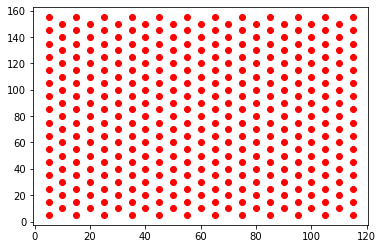

In [204]:
#train_in1, dx_out1[0]

#plt.scatter(train_in1[:,0], train_in1[:,1], c="b")
plt.scatter(train_in1ro[:,0], train_in1ro[:,1], c="r")

### with MLP

In [78]:
in_size = train_in1.shape[-1]
out_size = dx_out1.shape[-1]
h_size = [100, 100, 100, 100, 100, 100]

BATCH_SIZE = 250
LEARNING_RATE = 1e-2
n_epochs = 250

In [79]:
train_in1.shape, dx_out1.shape

((357, 2), (3583, 357, 1))

In [84]:
trainDS1x = Dataset(train_in1, dx_out1[0])
trainDS1y = Dataset(train_in1, dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [85]:
mlp1 = MLP(in_size, h_size, out_size).to(device)
mlp1.apply(weights_init)

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

In [86]:
mlp1, train_lossLog, val_lossLog = train_model(mlp1, lossf, opt, n_epochs, train1x_dataloader, test1x_dataloader)

Epoch: 0 - Loss: 3.010242223739624
Epoch: 10 - Loss: 0.6687828302383423
Epoch: 20 - Loss: 0.6619265675544739
Epoch: 30 - Loss: 0.6428014636039734
Epoch: 40 - Loss: 0.6424713134765625
Epoch: 50 - Loss: 0.6440862417221069
Epoch: 60 - Loss: 0.6429523229598999
Epoch: 70 - Loss: 0.6314521431922913
Epoch: 80 - Loss: 0.643785297870636
Epoch: 90 - Loss: 0.6440505385398865
Epoch: 100 - Loss: 0.6432765126228333
Epoch: 110 - Loss: 0.6391714215278625
Epoch: 120 - Loss: 0.6314977407455444
Epoch: 130 - Loss: 0.6352776288986206
Epoch: 140 - Loss: 0.6476345062255859
Epoch: 150 - Loss: 0.6495599746704102
Epoch: 160 - Loss: 0.6458202004432678
Epoch: 170 - Loss: 0.6423128247261047
Epoch: 180 - Loss: 0.6410287618637085
Epoch: 190 - Loss: 0.6497607231140137
Epoch: 200 - Loss: 0.6433365941047668
Epoch: 210 - Loss: 0.6408366560935974
Epoch: 220 - Loss: 0.6439505815505981
Epoch: 230 - Loss: 0.630009651184082
Epoch: 240 - Loss: 0.6178745031356812
Epoch: 250 - Loss: 0.6392739415168762


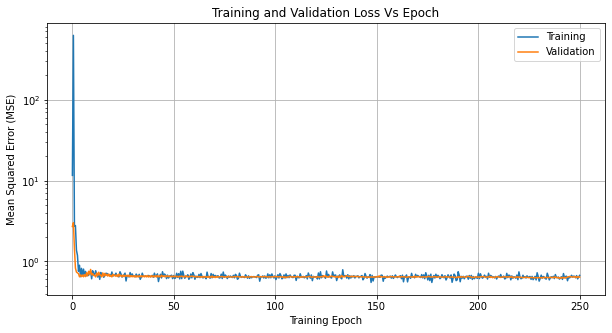

In [87]:
fig = plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, n_epochs, len(train_lossLog)), train_lossLog)
plt.plot(np.linspace(0, n_epochs, len(val_lossLog)), val_lossLog)
plt.xlabel("Training Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale("log")
title = plt.title("Training and Validation Loss Vs Epoch")
legend = plt.legend(["Training", "Validation"])
plt.grid()

In [169]:
test_outputs = predict_model(mlp1, test1x_dataloader)
max(test_outputs[:,0] - dx_out1[0,:,0])

-2.834860013687134

C:\Users\exy053\AppData\Local\Temp/ipykernel_304548/3089528512.py:8: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  ctr = ax.tricontourf(x_, y_, val_, cmap="viridis", edgecolor=None)


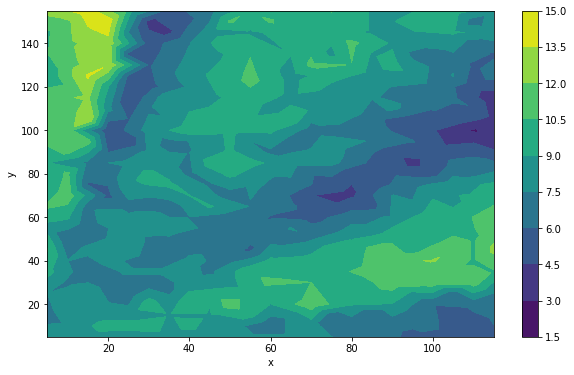

In [181]:
x_, y_ = train_in1[:,0], train_in1[:,1]
val_ = dx_out1[0,:,0] - test_outputs[:,0]

fig1 = plt.figure(figsize=(10, 6))
ax = fig1.add_subplot()
ax.set_xlabel('x')
ax.set_ylabel('y')
ctr = ax.tricontourf(x_, y_, val_, cmap="viridis", edgecolor=None)
plt.colorbar(ctr)

### with GPR

In [101]:
gpr1 = GPRmodel(K=kernel1, restarts=5, alpha=1e-3, data=[train_in1, dx_out1[1]])

In [119]:
mean

array([[ 1.85697265e-99,  1.11394187e-90,  9.04522153e-83, ...,
         3.38304773e-82,  4.16630870e-90,  6.94535460e-99],
       [ 2.48518285e-88,  1.49078622e-79,  1.21052022e-71, ...,
         4.52752615e-71,  5.57576276e-79,  9.29495445e-88],
       [ 1.21962678e-78,  7.31617314e-70,  5.94074149e-62, ...,
         2.22192590e-61,  2.73635785e-69,  4.56158604e-78],
       ...,
       [-3.20370599e-78, -1.92180657e-69, -1.56050928e-61, ...,
        -4.66172501e-61, -5.74103205e-69, -9.57046304e-78],
       [-6.52805867e-88, -3.91598545e-79, -3.17978495e-71, ...,
        -9.49900349e-71, -1.16982626e-78, -1.95013351e-87],
       [-4.87788106e-99, -2.92609369e-90, -2.37599164e-82, ...,
        -7.09782365e-82, -8.74114904e-90, -1.45717430e-98]])

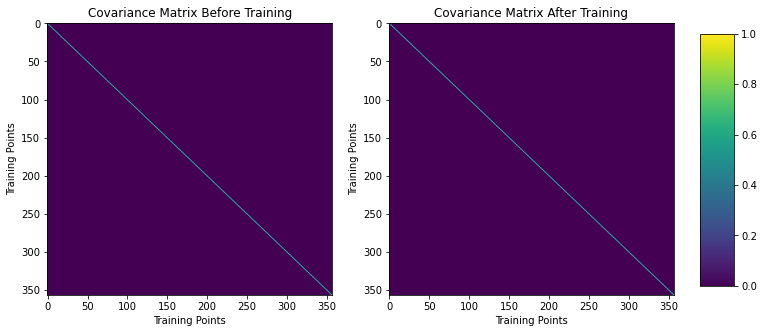

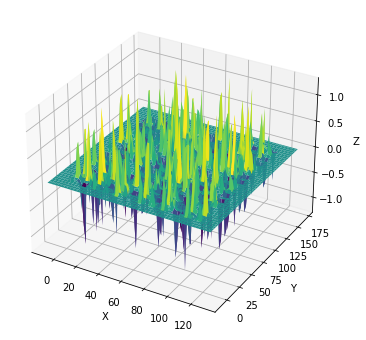

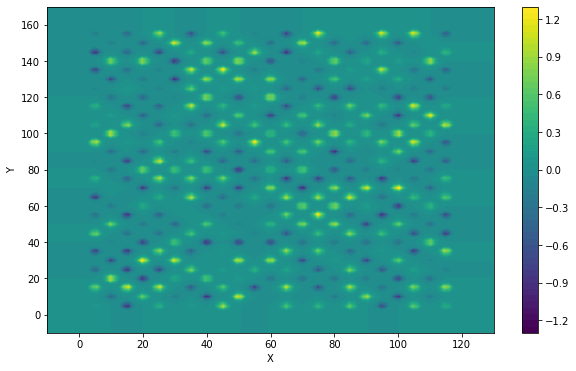

In [116]:
plot_Kmatrix(gpr1)
x_coords, y_coords, mean, std, cov = Fsurface(gpr=gpr1, density=100)
plot_Fsurface(x_coords, y_coords, mean, typ="both")

# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

### with MLP

In [63]:
in_size = train_in.shape[-1]
out_size = train_out.shape[-1]
h_size = [2**10, 2**9, 2**8, 2**8]

BATCH_SIZE = 100
LEARNING_RATE = 1e-4
n_epochs = 250

In [64]:
trainDS = Dataset(train_inST, train_outST)
valDS = Dataset(val_inST, val_outST)
testDS = Dataset(test_inST, test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [65]:
mlp1 = MLP(in_size, h_size, out_size).to(device)
mlp1.apply(weights_init)
# print(torch.cuda.is_available())   ### TODO: GPU

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

def custom_loss(target, output):   ### TODO: Quantile loss
    return torch.mean((output - target)**2)

In [20]:
mlp1, train_lossLog, val_lossLog = train_model(mlp1, lossf, opt, n_epochs, train_dataloader, val_dataloader)

Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training:   0%|          | 0/36 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

In [21]:
test_outputs = predict_model(mlp1, test_dataloader)

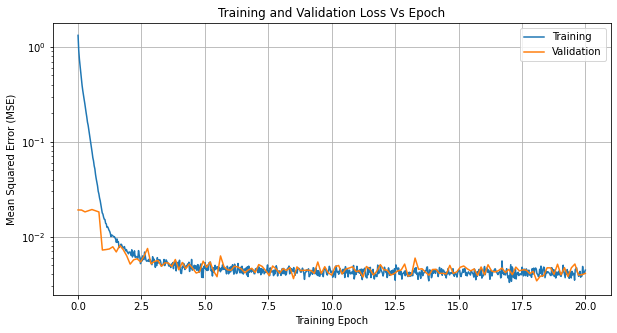

In [22]:
fig = plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, n_epochs, len(train_lossLog)), train_lossLog)
plt.plot(np.linspace(0, n_epochs, len(val_lossLog)), val_lossLog)
plt.xlabel("Training Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale("log")
title = plt.title("Training and Validation Loss Vs Epoch")
legend = plt.legend(["Training", "Validation"])
plt.grid()

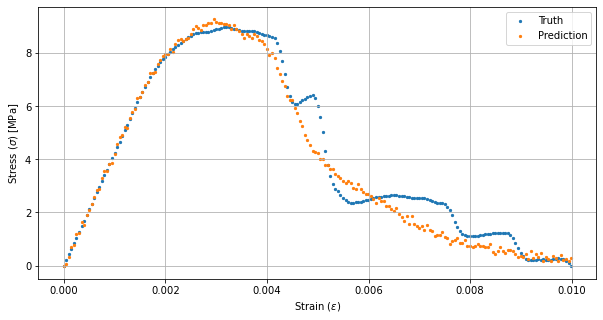

In [23]:
fig = plt.figure(figsize=(10, 5))
plt.scatter(perOUT[0], test_out[33]+perOUT[1], s=5, label="Truth")
plt.scatter(perOUT[0], test_outputs[33]+perOUT[1], s=5, label="Prediction")
plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.legend()
plt.grid()

### with GPR

In [ ]:
GPRmodel.fit(train_in[:500], train_out[:500])

y_mean, y_std = GPRmodel.predict(test_in, return_std=True)

In [ ]:
PLTidx = 1235

fig = plt.figure(num=1, figsize=(10,5))

plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.plot(perOUT[0], test_out[0]+perOUT[1], 'r-', label="Truth")
plt.plot(perOUT[0], y_mean[PLTidx]+perOUT[1], 'b-', label="Prediction")
plt.fill_between(perOUT[0], y_mean[PLTidx]+perOUT[1]-1.96*y_std[PLTidx], y_mean[PLTidx]+perOUT[1]+1.96*y_std[PLTidx], alpha=0.2)

plt.grid()
plt.legend()


# The End 